# Evaluating robustness
With parameter sets generated from multi-omics data and enzyme kinetic databases, RobustNet constructs an ensemble of stochastic kinetic models to simulate metabolic responses to engineering interventions, typically enzyme expression perturbations. Simulations are performed using a [continuation-like method](https://pubmed.ncbi.nlm.nih.gov/24972370/) that directly solves steady-state sensitivity equations along the perturbation trajectory, thereby avoiding repeated and computationally expensive time-domain integrations. 

In [1]:
import pandas as pd
from robustnet import Model

MODEL_FILE = '../../models/e_coli/e_coli_model.xlsx'
FLUXOMICS = '../../models/e_coli/measured_fluxes.xlsx'
FLUX_BOUNDS = '../../models/e_coli/flux_bounds.xlsx'
METABOLOMICS = '../../models/e_coli/measured_metabolites.xlsx'
PROTEOMICS = '../../models/e_coli/measured_enzymes.xlsx'
KINETIC_PARAMETERS = '../../models/e_coli/measured_kinetic_parameters.xlsx'

model = Model('ecoli')
model.read_from_file(MODEL_FILE)

flux_data = pd.read_excel(FLUXOMICS, header=0, index_col=0)
flux_bounds = pd.read_excel(FLUX_BOUNDS, header=0, index_col=0)

model.load_priors(
    'fluxomics',
    data=flux_data.iloc[:,0],
    std=flux_data.iloc[:,1],
)
fit_res = model.estimate_reference_fluxes(
    bounds={rxn: tuple(row) for rxn, row in flux_bounds.iterrows()},
    exclude_metabolites=None,
    optimizer='scipy',
    method='COBYQA',
    tol=1e-8
)

metab_data = pd.read_excel(METABOLOMICS, header=0, index_col=0)
enz_data = pd.read_excel(PROTEOMICS, header=0, index_col=0)
kparam_data = pd.read_excel(KINETIC_PARAMETERS, header=0, index_col=0)

model.load_priors(
    'reference_fluxes',
    data=fit_res.estimated_fluxes,
    std=fit_res.estimated_flux_errors
)
model.load_priors(
    'metabolomics', 
    data=metab_data.iloc[:,0], 
    std=metab_data.iloc[:,1],
)
model.load_priors(
    'proteomics', 
    data=enz_data.iloc[:,0], 
    std=enz_data.iloc[:,1],
)
model.load_priors(
    'kparameters',
    data=kparam_data.iloc[:,0],
    std=kparam_data.iloc[:,1]
)
samp_res = model.generate_parameter_sets(
    alpha=None,
    n_tunes=5000,
    n_samples=2000,
    n_chains=10,
    n_jobs=10
)

WARNING (pytensor.tensor.blas): Using NumPy C-API based implementation for BLAS functions.
INFO: Fluxes to fit: ACK, ACON, AKGDH, CS, EDA, EDD, ENO, FBA, FUMS, G6PD, GAPD, GND, GlcPTS, ICD, ICL, MALS, MDH, ME1, ME2, NNT, PDH, PFK, PGI, PGK, PGL, PGM, PPC, PPCK, PTA, PYK, RPE, RPI, SDH, SUCOAS, TAL, TKT1, TKT2, TPI


Reference flux fitting


SSR 5985.660: 00:34 


Parameter sampling


70000 samples: 08:22


## Simulating enzyme perturbations
Using the same *E. coli* model, assume that the parameter sampling procedure has already been completed and the returned samp_res stores sampled metabolite concentrations, enzyme concentrations, and kinetic parameters for ensemble model construction (see [Parameterizing the model](https://robustnet.readthedocs.io/en/latest/parameterize_model.html) for more details). The `evaluate_robustness` can then be used to simulate perturbations of specified enzyme(s). 

For example, a 10-fold overexpression of pyruvate dehydrogenase relative to its reference-state expression level can be simulated as follows:

In [3]:
metab_sets = samp_res.sampled_metabolite_concentrations
enz_sets = samp_res.sampled_enzyme_concentrations
kparam_sets = pd.concat(
    (samp_res.sampled_kinetic_parameters, metab_sets), 
    axis=1
)

model.load_parameter_sets(
    mconc_set=metab_sets,
    econc_set=enz_sets,
    kparam_set=kparam_sets
)
rob_res = model.evaluate_robustness(
    perturb_enzymes=['PDH'],
    fold_change=(1, 10),
    exclude_metabolites=['Hcyt', 'Hper'],
    n_steps=300,
    n_models=1000,
    n_jobs=100
)

INFO: Perturb enzyme PDH (1, 10)


<div class="alert alert-info">
<b>Note:</b> <br></br>
Sensitivities are not explicitly calculated for certain metabolites, such as end metabolites or metabolites that appear only in rate expressions as activators or inhibitors and do not participate directly as substrates or products in the stoichiometric network. Their concentrations are instead treated as regular kinetic parameters. To account for these metabolites, the input `kparam_set` should include both sampled kinetic parameter sets and sampled metabolite concentration sets corresponding to these metabolites.
</div>

The robustness of the metabolic system can be evaluated from the probability of ensemble models remaining viable across the perturbation range, which can be visualized using:

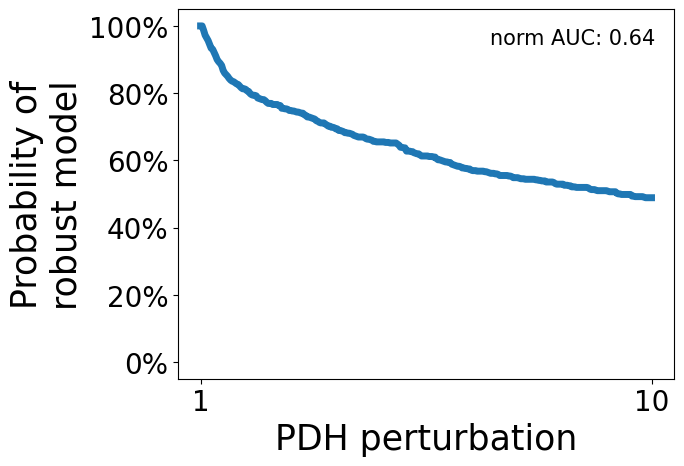

In [7]:
rob_res.robust_model_probability(out_dir=None, show_fig=True)

The robustness index provides a single quantitative metric of system robustness and is defined as the normalized area under the survival probability curve across the specified perturbation range.

In [13]:
print(f'Robustness index: {rob_res.robust_index:.3f}')

Robustness index: 0.638


Below demonstrates the robustness under a 2-fold downregulation of the same enzyme.

INFO: Perturb enzyme PDH (0.5, 1)


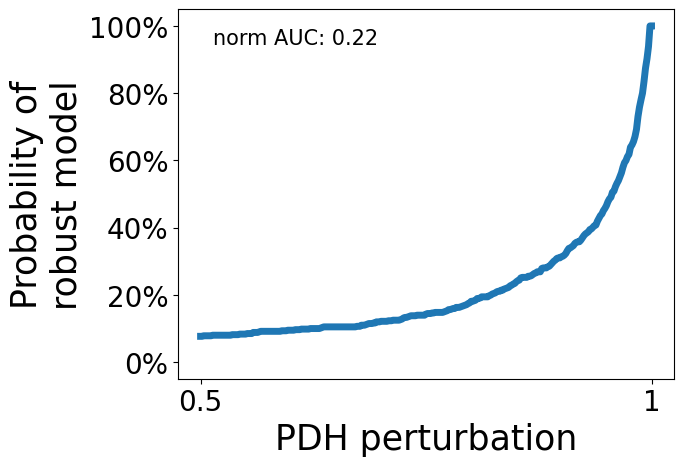

Robustness index: 0.217


In [17]:
rob_res = model.evaluate_robustness(
    perturb_enzymes=['PDH'],
    fold_change=(0.5, 1),
    exclude_metabolites=['Hcyt', 'Hper'],
    n_steps=300,
    n_models=1000,
    n_jobs=100
)
rob_res.robust_model_probability(out_dir=None, show_fig=True)
print(f'Robustness index: {rob_res.robust_index:.3f}')

The `fold_change` range must always include `1`, corresponding to the reference state. If `1` is used as one of the bounds, the perturbation is simulated only in a single direction, representing either upregulation or downregulation as shown above. If the fold-change interval spans across `1`, perturbations are simulated from the reference state toward both lower and upper bounds.

The following example demonstrates robustness analysis under up to 5-fold knockdown and 5-fold overexpression of the same enzyme.

INFO: Perturb enzyme PDH (0.2, 5)


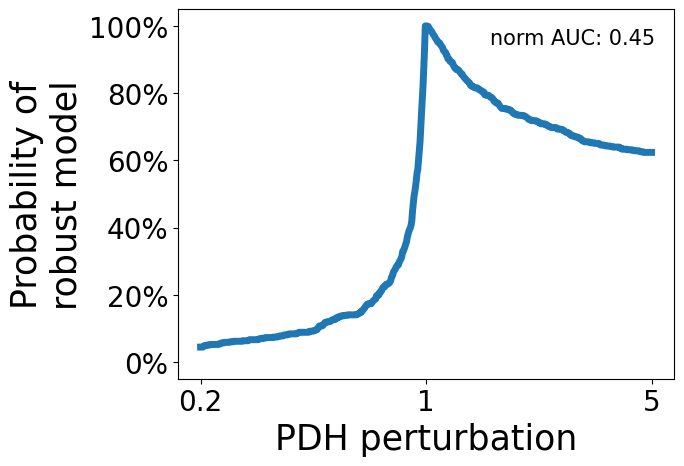

Robustness index: 0.448


In [4]:
rob_res = model.evaluate_robustness(
    perturb_enzymes=['PDH'],
    fold_change=(0.2, 5),
    exclude_metabolites=['Hcyt', 'Hper'],
    n_steps=300,
    n_models=1000,
    n_jobs=100
)
rob_res.robust_model_probability(out_dir=None, show_fig=True)
print(f'Robustness index: {rob_res.robust_index:.3f}')

Multiple-enzyme perturbations are also supported. For example, citrate synthase and 2-oxoglutarate dehydrogenase can be co-overexpressed with different fold-change ranges as follows:

INFO: Perturb enzyme GlcPTS (1, 2), PDH (1, 5)


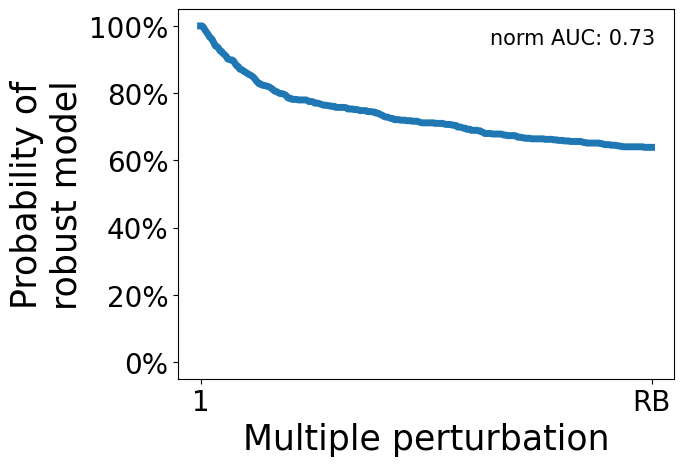

Robustness index: 0.730


In [17]:
rob_res = model.evaluate_robustness(
    perturb_enzymes=['GlcPTS', 'PDH'],
    fold_change={
        'GlcPTS': (1, 2), 
        'PDH': (1, 5)
    },
    exclude_metabolites=['Hcyt', 'Hper'],
    n_steps=300,
    n_models=1000,
    n_jobs=100
)
rob_res.robust_model_probability(out_dir=None, show_fig=True)
print(f'Robustness index: {rob_res.robust_index:.3f}')

Simultaneous knockdown and overexpression of different enzymes can also be simulated, as illustrated below.

INFO: Perturb enzyme GlcPTS (1, 2), PDH (1, 0.2)


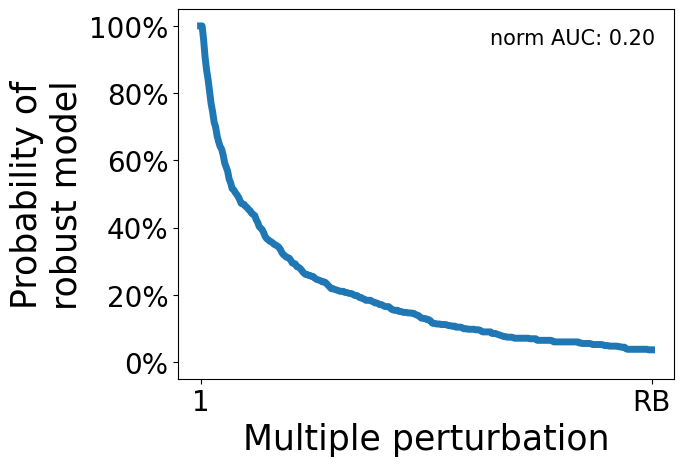

Robustness index: 0.197


In [18]:
rob_res = model.evaluate_robustness(
    perturb_enzymes=['GlcPTS', 'PDH'],
    fold_change={
        'GlcPTS': (1, 2), 
        'PDH': (1, 0.2)
    },
    exclude_metabolites=['Hcyt', 'Hper'],
    n_steps=300,
    n_models=1000,
    n_jobs=100
)
rob_res.robust_model_probability(out_dir=None, show_fig=True)
print(f'Robustness index: {rob_res.robust_index:.3f}')

In general, perturbations involving arbitrary combinations of enzymes and expression fold changes are supported.

## Inspecting metabolic responses
The simulation results can be further analyzed to investigate metabolic responses, including changes in steady-state metabolite concentrations and metabolic fluxes following perturbation. Metabolite responses can be visualized using the `metabolite_sensitivity` method (alias `bifurcation_diagram`).

Below, we demonstrate a 10-fold overexpression of GlcPTS as an example. 

In [20]:
rob_res = model.evaluate_robustness(
    perturb_enzymes=['GlcPTS'],
    fold_change=(1, 10),
    exclude_metabolites=['Hcyt', 'Hper'],
    n_steps=300,
    n_models=1000,
    n_jobs=100
)

INFO: Perturb enzyme GlcPTS (1, 10)


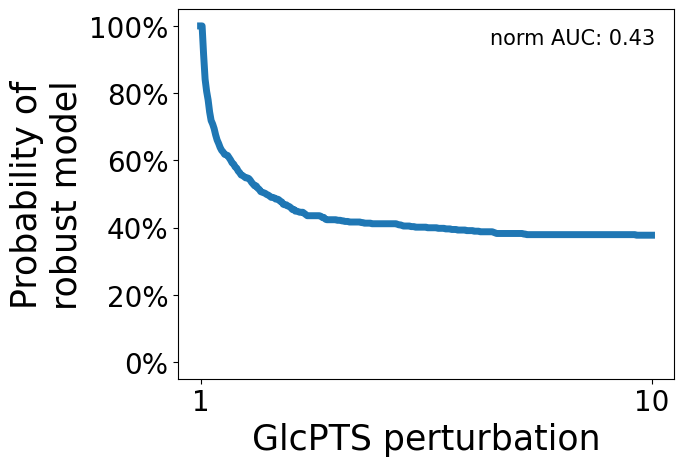

In [44]:
rob_res.robust_model_probability(out_dir=None, show_fig=True)

We first inspect the steady-state pyruvate concentration relative to its reference-state level in response to this perturbation.

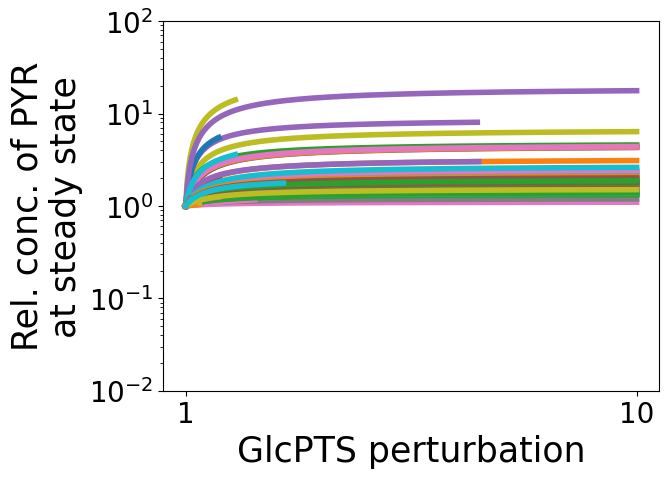

In [35]:
rob_res.metabolite_sensitivity(
    out_dir=None,
    kind='sample',
    metabolites=['PYR'],
    show_fig=True
)

Here metabolite response trajectories are visualized using sampled trajectories from ensemble models (the number of displayed trajectories can be controlled through `n_sets`). Alternatively, setting `kind` to "stats" displays a probability-density heatmap summarizing the responses across all models.

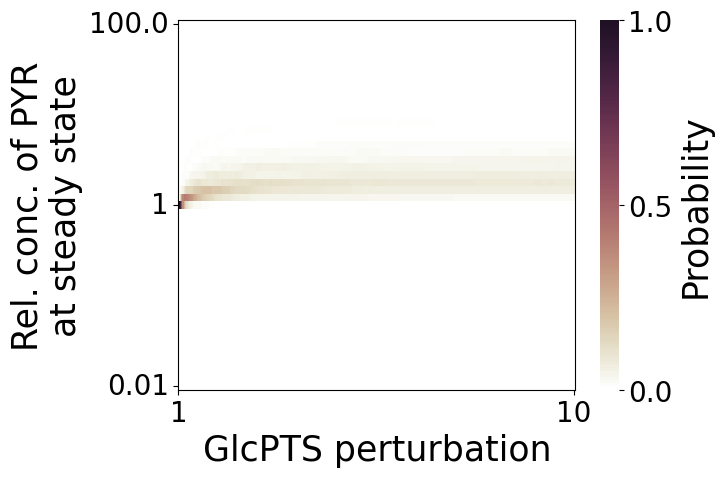

In [34]:
rob_res.metabolite_sensitivity(
    out_dir=None,
    kind='stats',
    metabolites=['PYR'],
    show_fig=True
)

The `metabolite_distribution` method visualizes the distribution of possible pyruvate concentrations throughout the perturbation process.

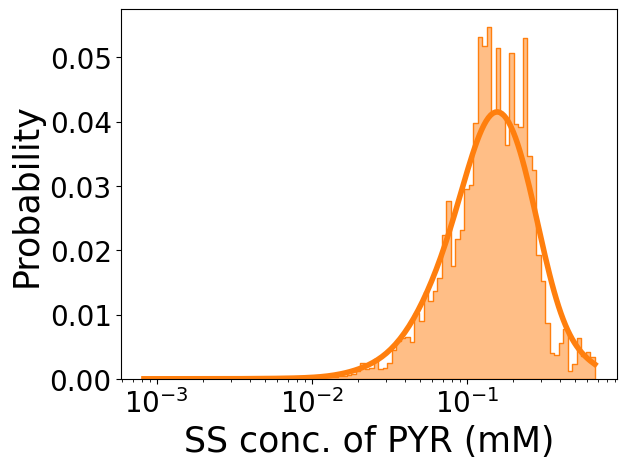

In [36]:
rob_res.metabolite_distribution(
    out_dir=None,
    metabolites=['PYR'],
    show_fig=True
)

In addition to metabolite concentrations, steady-state metabolic fluxes after perturbation can also be analyzed. The following example demonstrates how `flux_sensitivity` visualizes changes in pyruvate kinase flux relative to its reference-state value under perturbation.

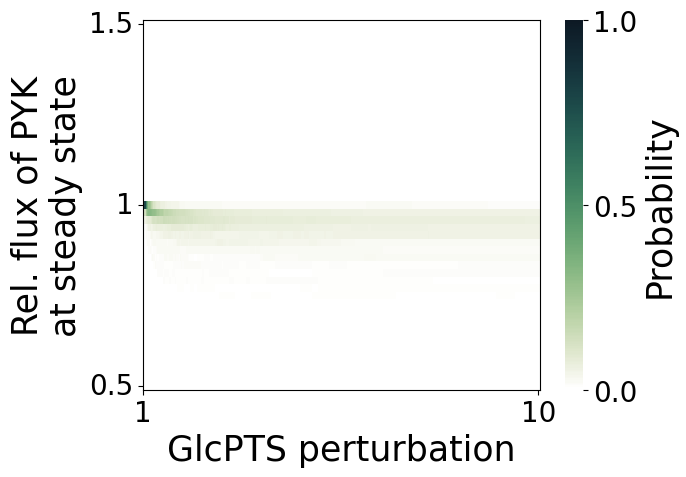

In [40]:
rob_res.flux_sensitivity(
    out_dir=None,
    kind='stats',
    reactions=['PYK'],
    show_fig=True
)

Similarly, the distribution of absolute flux values carried by the reaction during perturbation can be visualized as:

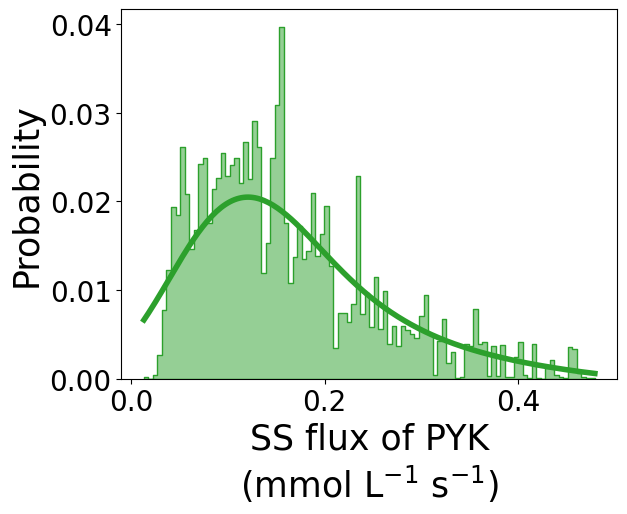

In [41]:
rob_res.flux_distribution(
    out_dir=None,
    reactions=['PYK'],
    show_fig=True
)

Diagnostics of the Jacobian matrix of the metabolic dynamic system is also provided, which determines the behavior and feasibility of the system under perturbations. Technically, if all real parts of eigenvalues of the Jacobian is negative, the system is able to reach a steady state again after perturbation. shows the 

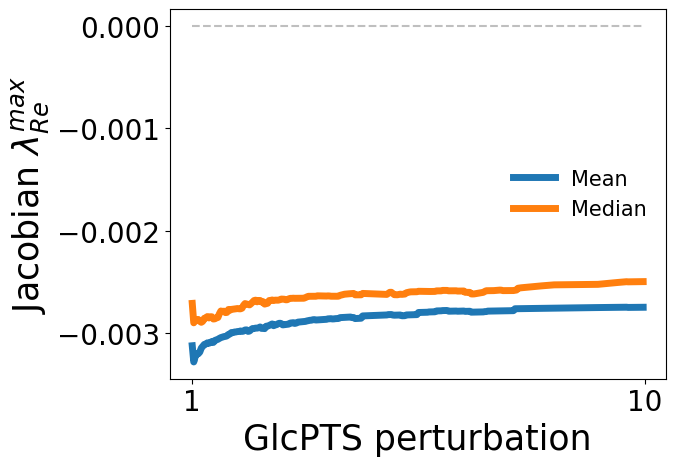

In [42]:
rob_res.eigreal_sensitivity(
    out_dir=None,
    show_fig=True
)

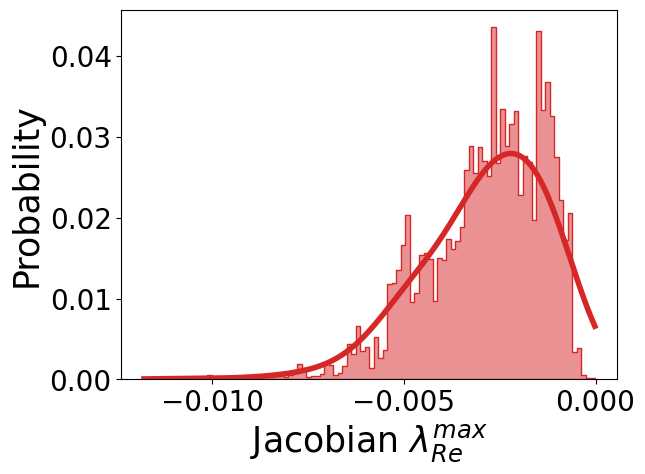

In [43]:
rob_res.eigreal_distribution(
    out_dir=None,
    show_fig=True
)